## Load datasets

In [ ]:
import pandas as pd
import numpy as np

# ukuran rumah
x = np.random.randint(50, 1000, 50)  # 50 sampel ukuran rumah antara 50 - 1000 m²
x = np.sort(x)  # Urutkan agar lebih mudah dilihat

# Fungsi Linear (harga rumah berdasarkan ukuran) + noise yang lebih besar
y = 5000 * x + np.random.normal(0, 120000, len(x))

df = pd.DataFrame({"x": x, "y": y})
df.head()

,x,y
0,51,266569.977484
1,84,470292.252672
2,102,395636.665294
3,130,524255.527690
4,141,479918.787335


In [ ]:
np.mean(df["x"])

564.1

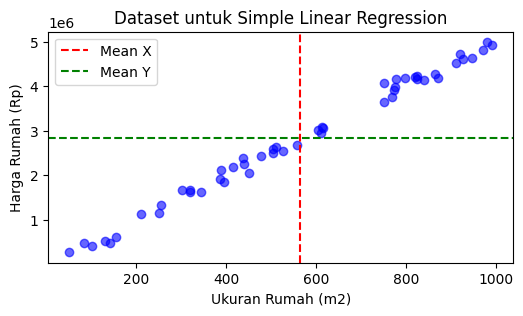

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 3))
plt.scatter(df["x"], df["y"], color="blue", alpha=0.6)
plt.axvline(np.mean(df["x"]), color="red", linestyle="--", label="Mean X")
plt.axhline(np.mean(df["y"]), color="green", linestyle="--", label="Mean Y")
plt.xlabel("Ukuran Rumah (m2)")
plt.ylabel("Harga Rumah (Rp)")
plt.legend()
plt.title("Dataset untuk Simple Linear Regression")
plt.show()

## Splitting data

In [ ]:
def train_test_split(X, y, test_size=0.2, random_state=None):
  if random_state:
    np.random.seed(random_state)

  X = pd.Series(X, name="X") if not isinstance(X, pd.Series) else X
  y = pd.Series(y, name="y") if not isinstance(y, pd.Series) else y

  n_samples = len(X)

  shuffle_indices = np.random.permutation(np.arange(n_samples))

  test_size = round(test_size * n_samples)
  train_size = n_samples - test_size

  train_indices = shuffle_indices[:train_size]
  test_indices = shuffle_indices[train_size:]

  X_train, X_test = X[train_indices], X[test_indices]
  y_train, y_test = y[train_indices], y[test_indices]

  return [X_train, X_test, y_train, y_test]

X = df.x
y = df.y

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.3)
# train_test_split([100, 200, 300, 400, 500], [100000, 180000, 250000, 310000, 370000], random_state=42)

## Make Model

In [ ]:
class SimpleLinearRegression():
  def __init__(self):
    self._beta1 = 0
    self._beta0 = 0
    self.errors = list()

  def fit(self, X_train, y_train):
    xbar = np.mean(X_train)
    ybar = np.mean(y_train)

    # calc beta1
    nemurator = np.sum((X_train - xbar) * (y_train - ybar))
    denominator = np.sum(np.power((X_train - xbar), 2))
    self._beta1 = nemurator / denominator

    # calc beta0
    self._beta0 = ybar - (self._beta1*xbar)

    self.errors.append(y_train - (self._beta0 + self._beta1 * X_train))

  def predict(self, X_test):
    return [(self._beta1 * x + self._beta0) for x in X_test]

## Implements model

In [ ]:
model = SimpleLinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [ ]:
model.errors

[13       134.266102
 39     79478.482292
 30    295028.654665
 45    -62966.763619
 17    216006.492829
 48     44053.133744
 26    -25193.793948
 25   -103933.903512
 32   -116549.854632
 19   -194619.489434
 12    -89998.855524
 4    -188146.831323
 37     71205.634280
 8      83233.395277
 3     -87765.467616
 6     106643.391195
 41    -69760.735982
 46   -132493.172314
 47    -85060.576282
 15   -122054.721656
 9     178179.212067
 16    124819.445005
 24    -93191.661654
 34     81355.735968
 31   -144100.604225
 0      57051.277159
 44     78378.043916
 27   -123566.446139
 33     27694.224103
 5    -128408.995955
 29    -21689.938711
 11     91580.867975
 36    169292.337427
 1      92639.682291
 21     -7272.463770
 dtype: float64]

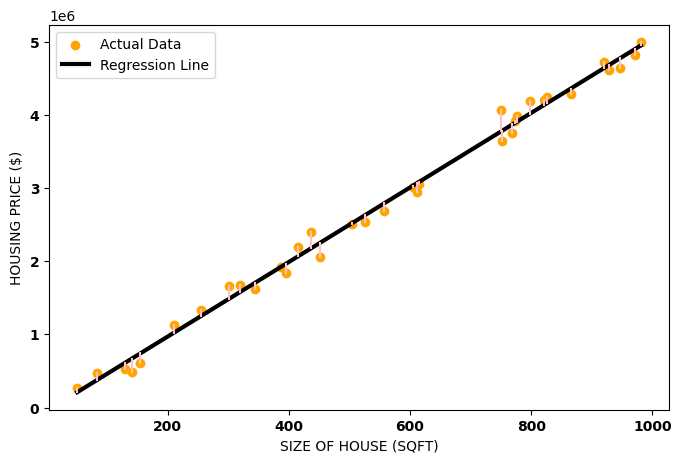

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(X_train, y_train, color='orange', label="Actual Data")

x_range = np.linspace(min(X_train), max(X_train), 100)
y_pred_range = model._beta0 + model._beta1 * x_range
plt.plot(x_range, y_pred_range, color='black', linewidth=3, label="Regression Line")

y_pred_train = model.predict(X_train)
for i in range(len(X_train)):
    plt.plot([X_train.iloc[i], X_train.iloc[i]],
             [y_train.iloc[i], y_pred_train[i]],
             color='pink', linewidth=1.5)

plt.xlabel("SIZE OF HOUSE (SQFT)")
plt.ylabel("HOUSING PRICE ($)")
plt.xticks(fontsize=10, fontweight='bold')
plt.yticks(fontsize=10, fontweight='bold')
plt.legend()
plt.show()

## Evaluation

In [ ]:
class RegressionEvaluation():
  def mean_squere_error(self, y_true, y_pred):
    return np.mean(np.power((y_true - y_pred), 2))

  def root_mean_squere_error(self, y_true, y_pred):
    return np.sqrt(self.mean_squere_error(y_true, y_pred))

  def mean_absolute_error(self, y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

  def r2_squared(self, y_true, y_pred):
    rss = np.sum(np.power((y_true - y_pred), 2))
    tss = np.sum(np.power((y_true - np.mean(y_true)), 2))
    return 1 - (rss / tss) if tss != 0 else 0

  def make_report(self, y_true, y_pred):
    report = {
        "MSE": self.mean_squere_error(y_true, y_pred),
        "MAE": self.mean_absolute_error(y_true, y_pred),
        "RMSE": self.root_mean_squere_error(y_true, y_pred),
        "R2 Squared": self.r2_squared(y_true, y_pred),
    }
    return pd.DataFrame([report])

## Implements matrixs evaluation

In [ ]:
pd.options.display.float_format = "{:.5f}".format

eval = RegressionEvaluation()
eval.make_report(y_test, y_pred)

,MSE,MAE,RMSE,R2 Squared
0,13017159676.94073,91133.06176,114092.76786,0.99235


In [ ]:
pd.concat([pd.DataFrame(y_test).reset_index(drop=True),
           pd.DataFrame(y_pred, columns=["ŷ"]).reset_index(drop=True)], axis=1)

,y,ŷ
0,395636.66529,469361.95405
1,4532538.29805,4596284.21905
2,4169467.11795,3918653.77307
3,2643334.68208,2553202.94959
4,4131761.35792,4234541.65014
5,1620390.44148,1574969.52381
6,2581135.37039,2522633.15503
7,2249946.20924,2186365.41492
8,4929308.24356,5003881.47979
9,2424221.42688,2379974.11377


In [ ]:
test_data = df.loc[1]["x"]
print(test_data)

df.head()

84.0


,x,y
0,51,266569.97748
1,84,470292.25267
2,102,395636.66529
3,130,524255.52769
4,141,479918.78734


In [ ]:
model.predict([test_data])

[377652.5703805025]

Kesimpulan model dengan